# Logical Resource Models

This notebook compares symbolic/logical resource approaches without promoting new dependencies.

Corpus anchors: `QRE2`, `QRE4`, `PRIM5`, `PRIM14`, `PRIM15`, `IO4`, `IO5`, `IO7`, `IO8`.

Compact object: the same toy QCFD timestep expressed as a resource table.


tooling atlas output directory: .cache\tooling_atlas


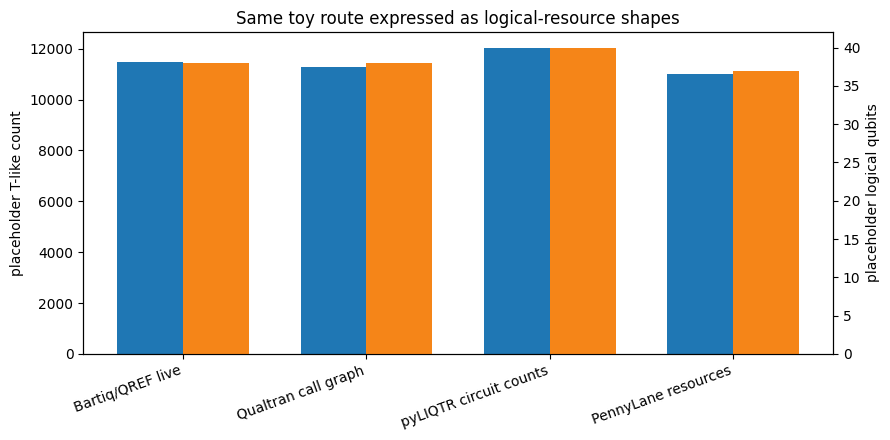

qualtran installed: True
pennylane installed: False
pyLIQTR installed: True
falsifiable check: live Bartiq/QREF count equals the explicit route formula


In [1]:
from pathlib import Path
import importlib.util
import json
import math

import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = Path('.cache/tooling_atlas')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def has_module(name: str) -> bool:
    try:
        return importlib.util.find_spec(name) is not None
    except ModuleNotFoundError:
        return False


print(f'tooling atlas output directory: {OUTPUT_DIR}')

from pq_cfd import _bartiq_qref_resources as qre2_resources

assignments = {
    'N_x': 16, 'N_y': 16, 'N_t': 4, 'N_samples': 256,
    'q_site': 8, 'q_velocity': 4, 'q_population': 8, 'q_work': 14, 'q_observable': 4,
    'T_load': 4000, 'T_stream': 80, 'T_collide': 600, 'T_success': 40,
    'T_readout_sample': 18, 'p_load': 0.98, 'p_step': 0.997, 'p_readout': 0.98,
}
bartiq_routine = qre2_resources.evaluate_qre2_taylor_green_route(assignments)
bartiq_t = int(bartiq_routine.resources['t_count'].value)

models = [
    {'model': 'Bartiq/QREF live', 'T-like': bartiq_t, 'qubits': int(bartiq_routine.resources['logical_qubits'].value), 'status': 'live placeholder'},
    {'model': 'Qualtran call graph', 'T-like': 3800 + 4 * 720 + 256 * 18, 'qubits': 38, 'status': 'sandbox shape'},
    {'model': 'pyLIQTR circuit counts', 'T-like': 4200 + 4 * 680 + 256 * 20, 'qubits': 40, 'status': 'watch shape'},
    {'model': 'PennyLane resources', 'T-like': 3900 + 4 * 750 + 256 * 16, 'qubits': 37, 'status': 'sandbox shape'},
]

x = np.arange(len(models))
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(x - 0.18, [m['T-like'] for m in models], width=0.36, label='T-like count')
ax2 = ax1.twinx()
ax2.bar(x + 0.18, [m['qubits'] for m in models], width=0.36, color='#f58518', label='logical qubits')
ax1.set_xticks(x, [m['model'] for m in models], rotation=20, ha='right')
ax1.set_ylabel('placeholder T-like count')
ax2.set_ylabel('placeholder logical qubits')
ax1.set_title('Same toy route expressed as logical-resource shapes')
plt.tight_layout()
plt.show()

for package in ['qualtran', 'pennylane', 'pyLIQTR']:
    print(f'{package} installed:', has_module(package))

expected = assignments['T_load'] + assignments['N_t'] * (assignments['T_stream'] + assignments['T_collide'] + assignments['T_success']) + assignments['N_samples'] * assignments['T_readout_sample']
assert bartiq_t == expected
print('falsifiable check: live Bartiq/QREF count equals the explicit route formula')


In [2]:
# Sandbox package inventory: generated from .cache/tooling_atlas/installed_packages_report.json.
from pathlib import Path
import json

report_path = Path('.cache/tooling_atlas/installed_packages_report.json')
if report_path.exists():
    report = json.loads(report_path.read_text(encoding='utf-8'))
    rows = []
    for env_name, env in report.items():
        for package, info in env['packages'].items():
            rows.append({
                'env': env_name,
                'package': package,
                'version': info.get('version') or '',
                'import': 'ok' if info.get('import_ok') else 'blocked',
                'note': info.get('error') or '',
            })
    try:
        import pandas as pd
        display(pd.DataFrame(rows))
    except Exception:
        for row in rows:
            print(f"{row['env']:12s} {row['package']:16s} {row['version']:10s} {row['import']:8s} {row['note']}")
else:
    print('No sandbox report found yet. Run the package audit to create .cache/tooling_atlas/installed_packages_report.json.')

No sandbox report found yet. Run the package audit to create .cache/tooling_atlas/installed_packages_report.json.


## What This Cannot Prove

Different logical-resource tools can expose different accounting shapes, but placeholder agreement is not validation. Only paper-grounded formulas, route gates, and tests can turn a logical count into a project claim.
